<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## RNN many-to-one: SimpleRNN vs LSTM vs GRU

### El *adding problem*: ¿cuándo (y por qué) una LSTM/GRU supera a una RNN simple?

### 0 - Motivación

En una RNN simple, el gradiente que fluye hacia atrás en el tiempo se multiplica en cada paso por la matriz recurrente (y la derivada de la activación). Si la secuencia es larga, ese producto tiende a **desvanecerse** (o explotar): la red "olvida" lo que vio al principio y no puede aprender a usarlo. Las LSTM (Hochreiter & Schmidhuber, 1997) y las GRU (Cho et al., 2014) introducen **compuertas (gates)** y un camino aditivo para el estado de la celda, lo que permite que la información —y el gradiente— sobrevivan muchos pasos de tiempo.

Para *ver* esa diferencia necesitamos una tarea que exija memoria de largo plazo. Vamos a usar el **adding problem**, que es literalmente el benchmark que Hochreiter y Schmidhuber propusieron en el paper original de LSTM para demostrar que las RNN simples fallan. Es una evolución natural de nuestro ejemplo de la suma:

**La tarea:** cada muestra es una secuencia de longitud $T$ con **2 features por paso de tiempo**:
- *Feature 1:* un valor aleatorio uniforme en $[0, 1]$.
- *Feature 2:* una marca binaria. Solo **2 posiciones** de la secuencia tienen marca $= 1$ (una en la primera mitad, otra en la segunda); el resto vale $0$.

**El target:** la suma de los 2 valores marcados.

Para resolverla, el modelo debe: (1) detectar la primera marca, (2) *memorizar* el valor asociado durante decenas de pasos llenos de ruido, (3) detectar la segunda marca y sumar. Con $T$ pequeño cualquier RNN puede; con $T$ grande, la RNN simple no logra retener la información del principio de la secuencia.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, SimpleRNN, LSTM, GRU

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

### 1 - Generación de los datos sintéticos

Cada muestra tiene forma `(T, 2)`: la primera columna son los valores aleatorios y la segunda las marcas. Colocamos una marca en la primera mitad de la secuencia y otra en la segunda mitad para garantizar que siempre exista una dependencia "larga".

In [ ]:
def generar_datos(n_muestras, T, seed=None):
    """Genera datos del "adding problem".

    Retorna:
        X: array (n_muestras, T, 2) -> [valor aleatorio, marca]
        y: array (n_muestras,)      -> suma de los 2 valores marcados
    """
    rng = np.random.default_rng(seed)

    valores = rng.uniform(0, 1, size=(n_muestras, T))
    marcas = np.zeros((n_muestras, T))

    for i in range(n_muestras):
        idx_1 = rng.integers(0, T // 2)   # una marca en la primera mitad
        idx_2 = rng.integers(T // 2, T)   # otra marca en la segunda mitad
        marcas[i, idx_1] = 1
        marcas[i, idx_2] = 1

    X = np.stack([valores, marcas], axis=-1)   # (n, T, 2)
    y = (valores * marcas).sum(axis=1)          # suma de los valores marcados

    return X.astype("float32"), y.astype("float32")

In [ ]:
# Longitud de la secuencia: el parámetro clave de todo el experimento
T = 50

X_train, y_train = generar_datos(6000, T, seed=1)
X_val, y_val = generar_datos(1000, T, seed=2)

print("X_train:", X_train.shape, "-> (muestras, pasos de tiempo, features)")
print("y_train:", y_train.shape)

X_train: (6000, 50, 2) -> (muestras, pasos de tiempo, features)
y_train: (6000,)


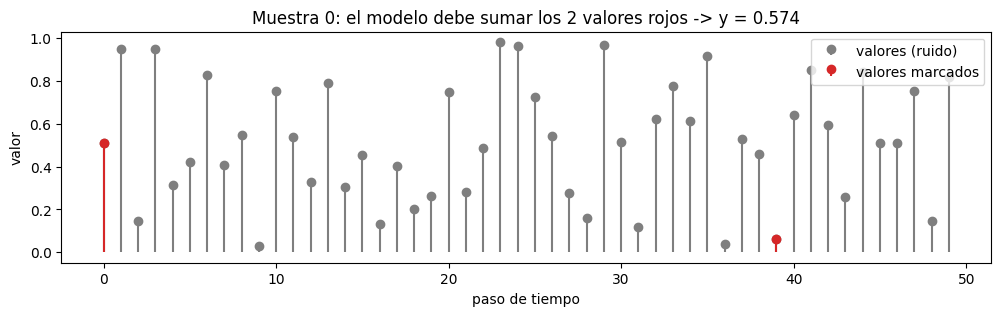

Posiciones marcadas: [ 0 39], separadas por 39 pasos
Target: 0.512 + 0.062 = 0.574


In [ ]:
# Visualicemos una muestra para entender la tarea
i = 0
valores_i = X_train[i, :, 0]
marcas_i = X_train[i, :, 1]
idx_marcados = np.where(marcas_i == 1)[0]

fig, ax = plt.subplots(figsize=(12, 3))
ax.stem(valores_i, basefmt=" ", linefmt="C7-", markerfmt="C7o", label="valores (ruido)")
ax.stem(idx_marcados, valores_i[idx_marcados], basefmt=" ",
        linefmt="C3-", markerfmt="C3o", label="valores marcados")
ax.set_xlabel("paso de tiempo")
ax.set_ylabel("valor")
ax.set_title(f"Muestra {i}: el modelo debe sumar los 2 valores rojos -> y = {y_train[i]:.3f}")
ax.legend()
plt.show()

print(f"Posiciones marcadas: {idx_marcados}, separadas por {idx_marcados[1]-idx_marcados[0]} pasos")
print(f"Target: {valores_i[idx_marcados[0]]:.3f} + {valores_i[idx_marcados[1]]:.3f} = {y_train[i]:.3f}")

### 2 - Baseline: ¿qué MSE tiene un modelo que no aprende nada?

Este paso es clave para interpretar los resultados. El target es la suma de 2 uniformes en $[0,1]$, así que su media es $1.0$ y su varianza es $2 \cdot \frac{1}{12} \approx 0.167$.

Un modelo que ignora la entrada y **siempre predice la media** obtiene un MSE igual a la varianza del target, $\approx 0.167$. Este es nuestro "piso de no-aprendizaje": si un modelo se estanca cerca de ese valor, significa que **no logró usar la información de la secuencia**.

In [ ]:
baseline_mse = np.mean((y_val - y_train.mean()) ** 2)
print(f"Media del target: {y_train.mean():.3f}")
print(f"MSE del baseline (predecir siempre la media): {baseline_mse:.4f}")

Media del target: 0.998
MSE del baseline (predecir siempre la media): 0.1612


### 3 - Los tres modelos a comparar

Definimos las tres arquitecturas con **exactamente el mismo protocolo**: misma cantidad de unidades ocultas, mismo optimizador, mismos datos, mismas épocas. La única variable es la celda recurrente.

Observen la cantidad de parámetros: para $h$ unidades y entrada de dimensión $d$, la RNN simple tiene $h(h+d+1)$ parámetros, la GRU el triple (3 compuertas/candidato) y la LSTM el cuádruple (4). Las compuertas no son gratis, pero veremos qué compran.

In [ ]:
UNIDADES = 32

def crear_modelo(celda_recurrente, nombre):
    model = Sequential(name=nombre)
    model.add(Input(shape=(T, 2)))
    model.add(celda_recurrente(UNIDADES))
    model.add(Dense(1))
    model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))
    return model

arquitecturas = {
    "SimpleRNN": SimpleRNN,
    "LSTM": LSTM,
    "GRU": GRU,
}

for nombre, celda in arquitecturas.items():
    m = crear_modelo(celda, nombre)
    print(f"{nombre:10s} -> {m.count_params():>6,} parámetros")
    print(m.summary())

SimpleRNN  ->  1,153 parámetros


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,489 (13.63 KB)

 Trainable params: 3,489 (13.63 KB)

 Non-trainable params: 0 (0.00 B)

None


### 4 - Entrenamiento y comparación

Entrenamos los tres modelos y guardamos sus curvas de pérdida de validación.

In [ ]:
EPOCAS = 30
BATCH = 64

historias = {}
modelos = {}

for nombre, celda in arquitecturas.items():
    tf.random.set_seed(SEED)  # misma inicialización aleatoria para una comparación justa
    model = crear_modelo(celda, nombre)
    print(f"Entrenando {nombre}...")
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCAS, batch_size=BATCH, verbose=0,
    )
    historias[nombre] = hist.history
    modelos[nombre] = model
    print(f"  val_mse final: {hist.history['val_loss'][-1]:.4f}")

Entrenando SimpleRNN...
  val_mse final: 0.0254
Entrenando LSTM...
  val_mse final: 0.0049
Entrenando GRU...
  val_mse final: 0.0021


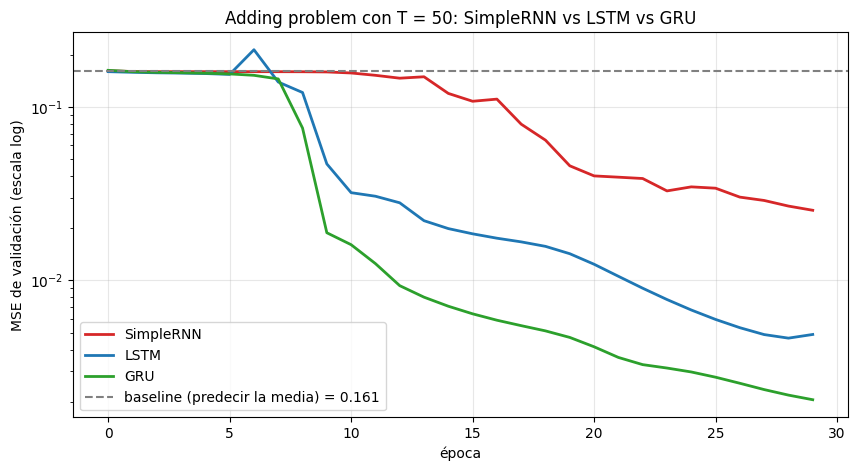

In [ ]:
colores = {"SimpleRNN": "C3", "LSTM": "C0", "GRU": "C2"}

fig, ax = plt.subplots(figsize=(10, 5))
for nombre, h in historias.items():
    ax.plot(h["val_loss"], color=colores[nombre], label=nombre, linewidth=2)

ax.axhline(baseline_mse, color="gray", linestyle="--",
           label=f"baseline (predecir la media) = {baseline_mse:.3f}")
ax.set_yscale("log")
ax.set_xlabel("época")
ax.set_ylabel("MSE de validación (escala log)")
ax.set_title(f"Adding problem con T = {T}: SimpleRNN vs LSTM vs GRU")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Verifiquemos con predicciones concretas:

In [ ]:
X_demo, y_demo = generar_datos(5, T, seed=99)

print(f"{'target':>8s}", *[f"{n:>12s}" for n in modelos], sep=" | ")
preds = {n: m.predict(X_demo, verbose=0).ravel() for n, m in modelos.items()}
for j in range(5):
    print(f"{y_demo[j]:8.3f}", *[f"{preds[n][j]:12.3f}" for n in modelos], sep=" | ")

  target |    SimpleRNN |         LSTM |          GRU
   0.954 |        0.842 |        0.991 |        1.008
   1.082 |        1.205 |        1.135 |        1.154
   0.615 |        0.610 |        0.558 |        0.605
   0.749 |        0.731 |        0.767 |        0.732
   1.526 |        1.372 |        1.343 |        1.480


### 5 - El experimento clave: ¿qué pasa cuando crece la longitud de la secuencia?

Si el problema de la SimpleRNN es el desvanecimiento del gradiente a través del tiempo, entonces su rendimiento debería **degradarse a medida que crece $T$**, mientras que LSTM y GRU deberían mantenerse. Repetimos el experimento para varias longitudes.

> Esta celda entrena 9 modelos (3 arquitecturas × 3 longitudes). En GPU tarda unos pocos minutos; en CPU puede tardar más. Pueden reducir `EPOCAS_SWEEP` si necesitan acelerar.

In [ ]:
LONGITUDES = [10, 30, 50]
EPOCAS_SWEEP = 20

resultados = {nombre: [] for nombre in arquitecturas}

for T_i in LONGITUDES:
    Xtr, ytr = generar_datos(6000, T_i, seed=1)
    Xva, yva = generar_datos(1000, T_i, seed=2)
    for nombre, celda in arquitecturas.items():
        tf.random.set_seed(SEED)
        model = Sequential([Input(shape=(T_i, 2)), celda(UNIDADES), Dense(1)])
        model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(1e-3))
        hist = model.fit(Xtr, ytr, validation_data=(Xva, yva),
                         epochs=EPOCAS_SWEEP, batch_size=BATCH, verbose=0)
        mejor = min(hist.history["val_loss"])
        resultados[nombre].append(mejor)
        print(f"T={T_i:3d}  {nombre:10s}  mejor val_mse = {mejor:.4f}")

T= 10  SimpleRNN   mejor val_mse = 0.0139
T= 10  LSTM        mejor val_mse = 0.0066
T= 10  GRU         mejor val_mse = 0.0002
T= 30  SimpleRNN   mejor val_mse = 0.0313
T= 30  LSTM        mejor val_mse = 0.0085
T= 30  GRU         mejor val_mse = 0.0030
T= 50  SimpleRNN   mejor val_mse = 0.1574
T= 50  LSTM        mejor val_mse = 0.0363
T= 50  GRU         mejor val_mse = 0.0054


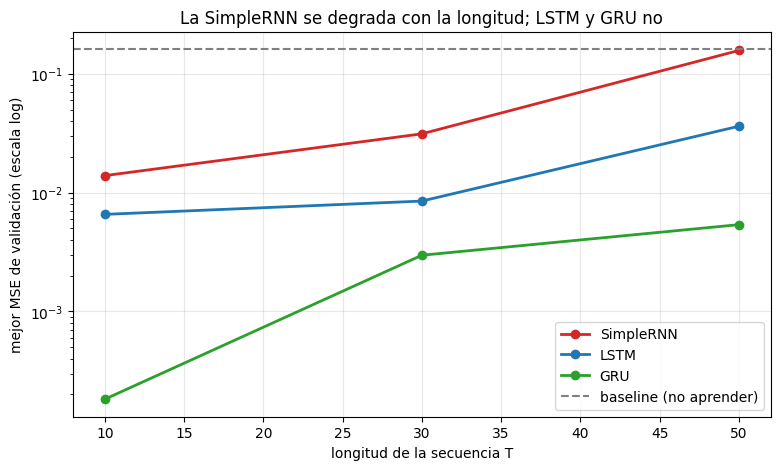

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for nombre, mses in resultados.items():
    ax.plot(LONGITUDES, mses, "o-", color=colores[nombre], label=nombre, linewidth=2)

ax.axhline(baseline_mse, color="gray", linestyle="--", label="baseline (no aprender)")
ax.set_yscale("log")
ax.set_xlabel("longitud de la secuencia T")
ax.set_ylabel("mejor MSE de validación (escala log)")
ax.set_title("La SimpleRNN se degrada con la longitud; LSTM y GRU no")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Interpretación:** con $T=10$ las tres arquitecturas resuelven la tarea — este es exactamente el régimen del ejemplo de la suma de 3 números, donde no se veía ninguna diferencia. A medida que $T$ crece, la SimpleRNN colapsa hacia el baseline mientras LSTM y GRU se mantienen. **La diferencia entre arquitecturas no es "una es mejor que otra en general", sino "una puede propagar información/gradiente a través de muchos pasos y la otra no".**

### 6 - (Opcional) Viendo el vanishing gradient directamente

Podemos medir cuánto influye cada paso de tiempo de la entrada sobre la predicción final, calculando el gradiente de la salida respecto de la entrada: $\left\| \frac{\partial \hat{y}}{\partial x_t} \right\|$ para cada $t$.

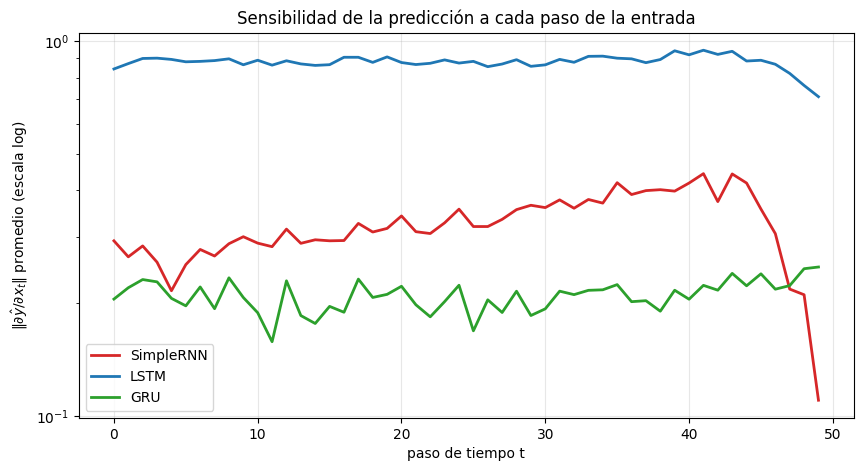

In [ ]:
X_grad, _ = generar_datos(256, T, seed=7)
X_grad_tf = tf.constant(X_grad)

fig, ax = plt.subplots(figsize=(10, 5))
for nombre, model in modelos.items():
    with tf.GradientTape() as tape:
        tape.watch(X_grad_tf)
        y_hat = model(X_grad_tf)
    grads = tape.gradient(y_hat, X_grad_tf)              # (n, T, 2)
    magnitud = tf.reduce_mean(tf.norm(grads, axis=-1), axis=0).numpy()  # promedio por paso t
    ax.plot(magnitud, color=colores[nombre], label=nombre, linewidth=2)

ax.set_yscale("log")
ax.set_xlabel("paso de tiempo t")
ax.set_ylabel(r"$\|\partial \hat{y} / \partial x_t\|$ promedio (escala log)")
ax.set_title("Sensibilidad de la predicción a cada paso de la entrada")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 7 - Conclusiones

1. **Con secuencias cortas no hay diferencia** entre SimpleRNN, LSTM y GRU — por eso el ejemplo de sumar 3 números no evidenciaba nada. Las tres resuelven la tarea con $T=10$.
2. **Con dependencias largas, la SimpleRNN colapsa al baseline**: su MSE equivale a predecir siempre la media, porque el gradiente se desvanece antes de llegar a los pasos iniciales.
3. **LSTM y GRU resuelven la tarea a cualquier longitud probada**, gracias a las compuertas y el camino aditivo de memoria. La GRU logra resultados comparables a la LSTM con ~25% menos parámetros — en la práctica suele ser la primera opción cuando el presupuesto de cómputo importa.
4. El costo de las compuertas es más parámetros y más cómputo por paso: RNN < GRU < LSTM (aprox. 1× / 3× / 4× para el mismo número de unidades).
